# Módulo 2 — Movimiento Browniano Geométrico

**Proyecto:** Métodos de Monte Carlo en Finanzas Cuantitativas  
**Autor:** Jorge Rodríguez Lázaro  
**Última actualización:** 2026-09-23

---

## Objetivo del módulo

Este módulo construye el modelo estándar para el precio de un activo financiero: el **Movimiento Browniano Geométrico (GBM)**. Partimos de las dos piezas del Módulo 1 — la simulación Monte Carlo y el movimiento browniano — y las aplicamos al problema de modelar precios reales.

El objetivo es triple:

1. Entender de dónde sale la fórmula del GBM y por qué es el modelo natural para precios.
2. Simular trayectorias de precios y visualizar su comportamiento.
3. Estimar los parámetros del modelo ($\mu$ y $\sigma$) a partir de datos reales de mercado.

## Estructura

| Sección | Tema | Conexión con el proyecto |
|---------|------|--------------------------|
| 1 | Del paseo aleatorio al GBM | Por qué modelamos logaritmos y de dónde sale la fórmula. |
| 2 | Simulación de trayectorias | Discretización de Euler-Maruyama e implementación vectorizada. |
| 3 | Estimación de parámetros | Calibración de μ y σ con datos reales de Yahoo Finance. |
| 4 | Validación | Comparación entre trayectorias simuladas y precio histórico real. |

## Referencias

- Glasserman, P. (2003). *Monte Carlo Methods in Financial Engineering*, cap. 3.
- Hull, J. C. (2018). *Options, Futures and Other Derivatives*, cap. 15.
- Shreve, S. E. (2004). *Stochastic Calculus for Finance II*, cap. 4.

> **Nota sobre el código.** Las funciones que aquí se derivan e implementan paso a paso (`simular_gbm`, `precio_mc`, `black_scholes`, `estimar_parametros`, …) viven además, en su versión canónica y con *type hints*, en el paquete `src/mcquant/`, cubiertas por la suite de tests de `tests/`. El notebook es la exposición; el paquete, la librería reutilizable. Se pueden importar con `from mcquant import ...`.

---

# Sección 1 — Del paseo aleatorio al GBM

## 1.1 Por qué no vale el movimiento browniano directo

El movimiento browniano $W_t$ tiene dos problemas como modelo de precios:

1. **Puede ser negativo.** $W_t \in \mathbb{R}$ para todo $t$, pero un precio $S_t > 0$ siempre.
2. **Los cambios son absolutos, no proporcionales.** En finanzas lo relevante es el cambio porcentual: una subida de 1€ en una acción de 10€ (10%) no es lo mismo que en una de 1000€ (0.1%). Un modelo aditivo no captura esto.

## 1.2 La solución: modelar las rentabilidades logarítmicas

Definimos la **rentabilidad logarítmica** entre dos instantes como:

$$
r_t = \log\frac{S_t}{S_{t-1}}
$$

Esta cantidad puede ser positiva o negativa (el precio sube o baja), no está acotada, y es **proporcional** al nivel del precio por construcción. Es el objeto natural a modelar.

El supuesto del GBM es que las rentabilidades logarítmicas son i.i.d. y normales:

$$
r_t \sim \mathcal{N}\!\left(\left(\mu - \frac{\sigma^2}{2}\right)\Delta t,\; \sigma^2 \Delta t\right)
$$

donde $\mu$ es la **rentabilidad esperada** (drift) y $\sigma$ es la **volatilidad**.

## 1.3 De las rentabilidades al precio: la fórmula del GBM

**Paso 1.** Dividimos $[0, T]$ en $N$ intervalos de longitud $\Delta t = T/N$. Los cocientes de precios se telescopan:

$$
\frac{S_T}{S_0} = \frac{S_1}{S_0} \cdot \frac{S_2}{S_1} \cdots \frac{S_N}{S_{N-1}}
\quad\Longrightarrow\quad
\log\frac{S_T}{S_0} = \sum_{i=1}^{N} r_i
$$

Esto no es un supuesto: es una igualdad algebraica que se cumple trayectoria a trayectoria, sea cual sea la evolución del precio.

**Paso 2.** Por el supuesto de 1.2, las $r_i$ son i.i.d. normales. Una suma de normales independientes es normal, y sus medias y varianzas se suman:

$$
\sum_{i=1}^{N} r_i \sim \mathcal{N}\!\left(N \left(\mu - \frac{\sigma^2}{2}\right)\Delta t,\; N \sigma^2 \Delta t\right) = \mathcal{N}\!\left(\left(\mu - \frac{\sigma^2}{2}\right)T,\; \sigma^2 T\right)
$$

**Paso 3.** Aquí hay un salto que conviene justificar: lo anterior es una afirmación *en distribución* ($\sim$), pero la fórmula final del GBM es una *igualdad* ($=$). El puente es general: si $X \sim \mathcal{N}(m, v)$, definimos

$$
Z := \frac{X - m}{\sqrt{v}}
$$

Como $Z$ es una transformación lineal de una normal, es normal, y calculando: $\mathbb{E}[Z] = 0$, $\operatorname{Var}(Z) = 1$. Despejando:

$$
X = m + \sqrt{v}\, Z, \qquad Z \sim \mathcal{N}(0, 1)
$$

y esto ya es una **igualdad entre variables aleatorias**, no solo en distribución: $Z$ no es un objeto nuevo e independiente, sino que está construida a partir de la propia $X$ — es la misma aleatoriedad, re-escalada para separar la parte determinista ($m$) del ruido puro ($Z$).

Aplicándolo a $X = \log(S_T/S_0)$ con $m = (\mu - \sigma^2/2)\,T$ y $v = \sigma^2 T$, y llamando $W_T := \sqrt{T}\, Z$ (que por construcción cumple $W_T \sim \mathcal{N}(0, T)$, exactamente la ley del movimiento browniano en el instante $T$ que vimos en el Módulo 1):

$$
\log\frac{S_T}{S_0} = \left(\mu - \frac{\sigma^2}{2}\right)T + \sigma W_T
$$

**Paso 4.** La igualdad anterior vale realización a realización, así que podemos aplicar la exponencial a ambos lados:

$$
\boxed{S_T = S_0 \, e^{\left(\mu - \frac{\sigma^2}{2}\right)T + \sigma W_T}}
$$

Toda la aleatoriedad de $S_T$ queda empaquetada en una única variable, $W_T$. De aquí sale directamente la receta de simulación: generar $Z \sim \mathcal{N}(0,1)$ y sustituir — es lo que haremos en la Sección 2.

## 1.4 La corrección $\sigma^2/2$ — corrección de Jensen

¿Por qué aparece $\mu - \sigma^2/2$ y no simplemente $\mu$?

Porque la esperanza de $e^X$ no es $e^{\mathbb{E}[X]}$ cuando $X$ es aleatoria: la exponencial es convexa, y la desigualdad de Jensen dice que $\mathbb{E}[e^X] \geq e^{\mathbb{E}[X]}$. Para una normal podemos calcular la esperanza de forma exacta y ver *cuánto* vale ese exceso.

**Proposición.** Si $X \sim \mathcal{N}(m, v)$, entonces $\mathbb{E}[e^X] = e^{m + v/2}$.

**Demostración.** Escribimos la esperanza como integral contra la densidad normal:

$$
\mathbb{E}[e^X] = \int_{-\infty}^{\infty} e^x \, \frac{1}{\sqrt{2\pi v}} \, e^{-\frac{(x-m)^2}{2v}} \, dx
= \int_{-\infty}^{\infty} \frac{1}{\sqrt{2\pi v}} \, e^{x - \frac{(x-m)^2}{2v}} dx
$$

El truco es **completar cuadrados** en el exponente. Ponemos todo sobre el mismo denominador y desarrollamos el numerador:

$$
x - \frac{(x-m)^2}{2v} = -\frac{(x-m)^2 - 2vx}{2v},
\qquad
(x-m)^2 - 2vx = x^2 - 2(m+v)x + m^2 = \big(x - (m+v)\big)^2 - 2mv - v^2
$$

Sustituyendo, la parte constante sale de la integral:

$$
\mathbb{E}[e^X] = e^{\frac{2mv + v^2}{2v}} \int_{-\infty}^{\infty} \frac{1}{\sqrt{2\pi v}} \, e^{-\frac{(x-(m+v))^2}{2v}} \, dx = e^{m + v/2} \cdot 1
$$

porque el integrando es exactamente la densidad de una $\mathcal{N}(m+v,\, v)$ — la misma campana, desplazada — y toda densidad integra 1. $\blacksquare$

Obsérvese que el resultado cuantifica a Jensen: el factor de exceso es $e^{v/2} > 1$, y crece con la varianza. A más incertidumbre, más infla la exponencial a la esperanza.

Queremos que $\mathbb{E}[S_T] = S_0 \, e^{\mu T}$ — el precio crece en promedio a tasa $\mu$. Si ponemos $m = (\mu - \sigma^2/2)T$ y $v = \sigma^2 T$:

$$
\mathbb{E}[S_T] = S_0 \cdot e^{(\mu - \sigma^2/2)T + \sigma^2 T/2} = S_0 \, e^{\mu T}
$$

El término $-\sigma^2/2$ compensa exactamente el exceso que introduce la exponencial, garantizando que la rentabilidad esperada del precio sea $\mu$ tal y como deseamos.

---

# Sección 2 — Simulación de trayectorias

## 2.1 La ecuación diferencial estocástica del GBM

En la Sección 1 llegamos a la fórmula del GBM acumulando rentabilidades logarítmicas discretas. La formulación continua del mismo modelo es una **ecuación diferencial estocástica (EDE)**:

$$
dS_t = \mu S_t\, dt + \sigma S_t\, dW_t
$$

La lectura es directa: en un intervalo infinitesimal, el cambio **proporcional** del precio

$$
\frac{dS_t}{S_t} = \mu\, dt + \sigma\, dW_t
$$

tiene una parte determinista ($\mu\,dt$, la tendencia) y una parte aleatoria ($\sigma\,dW_t$, ruido browniano escalado por la volatilidad). Es exactamente la idea de la Sección 1 — modelar cambios relativos, no absolutos — escrita en tiempo continuo.

La solución de esta EDE es la fórmula que ya conocemos:

$$
S_t = S_0 e^{\left(\mu - \frac{\sigma^2}{2}\right)t + \sigma W_t}
$$

Demostrar que esta expresión resuelve la EDE requiere el **lema de Itô** (Shreve, cap. 4), que en este módulo tomamos como resultado. A cambio, lo verificaremos numéricamente por Monte Carlo en 2.4.

## 2.2 Dos esquemas de simulación

Para simular en una malla temporal $0 = t_0 < t_1 < \dots < t_N = T$ con paso $\Delta t = T/N$ hay dos caminos.

**Esquema exacto.** Aplicamos la fórmula cerrada entre nodos consecutivos. Como los incrementos del browniano son independientes y $W_{t_{k+1}} - W_{t_k} \sim \mathcal{N}(0, \Delta t)$:

$$
S_{k+1} = S_k \cdot e^{\left(\mu - \frac{\sigma^2}{2}\right)\Delta t + \sigma \sqrt{\Delta t}\, Z_k}, \qquad Z_k \overset{\text{iid}}{\sim} \mathcal{N}(0,1)
$$

Este esquema es **exacto en distribución** para cualquier $\Delta t$: los valores simulados en los nodos tienen exactamente la ley del GBM, sin error de discretización.

**Euler–Maruyama.** Es la receta general para *cualquier* EDE: sustituir $dt \to \Delta t$ y $dW_t \to \sqrt{\Delta t}\, Z_k$ directamente en la ecuación:

$$
S_{k+1} = S_k \left(1 + \mu\, \Delta t + \sigma \sqrt{\Delta t}\, Z_k\right)
$$

Este esquema **sí** tiene error de discretización (desaparece cuando $\Delta t \to 0$), e incluso puede producir precios negativos si $Z_k$ toma un valor muy negativo.

¿Por qué estudiar Euler–Maruyama si tenemos el esquema exacto? Porque el GBM es la excepción, no la regla: la mayoría de los modelos relevantes en la práctica (volatilidad estocástica, modelos de tipos de interés...) **no tienen solución cerrada**, y Euler es el caballo de batalla para simularlos. El GBM es el laboratorio perfecto para estudiar su error, porque disponemos de la respuesta exacta contra la que medirlo (lo haremos en 2.5).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm, norm

# Mismo generador reproducible que en el Módulo 1
rng = np.random.default_rng(seed=42)

In [2]:
def simular_gbm(S0, mu, sigma, T, n_pasos, n_tray, rng):
    """Simula trayectorias de GBM con el esquema exacto.

    Devuelve una matriz (n_tray, n_pasos + 1); la columna k contiene S_{t_k}.
    """
    dt = T / n_pasos
    # Matriz de rentabilidades logarítmicas: cada una ~ N((μ - σ²/2)Δt, σ²Δt)
    log_rent = rng.normal((mu - 0.5 * sigma**2) * dt, sigma * np.sqrt(dt),
                          size=(n_tray, n_pasos))
    # log S_k = log S_0 + suma acumulada de rentabilidades → exponenciamos
    log_S = np.log(S0) + np.cumsum(log_rent, axis=1)
    # Añadimos la columna inicial S_0
    return np.hstack([np.full((n_tray, 1), S0), np.exp(log_S)])

## 2.3 Trayectorias: la media no es la trayectoria típica

Simulamos trayectorias a 5 años y las comparamos con dos curvas teóricas:

- **Media:** $\mathbb{E}[S_t] = S_0\, e^{\mu t}$ — garantizada por la corrección de Jensen de 1.4.
- **Mediana:** $\operatorname{med}(S_t) = S_0\, e^{(\mu - \sigma^2/2)t}$. Como la función exponencial es estrictamente creciente, la mediana de $S_t = e^{X}$ es $e^{\operatorname{med}(X)}$, y la mediana de una normal es su media.

Que la mediana quede **por debajo** de la media es la asimetría lognormal en acción: unas pocas trayectorias explosivas tiran de la media hacia arriba, mientras que la trayectoria "típica" crece solo a tasa $\mu - \sigma^2/2$. De hecho, podemos calcular qué fracción de trayectorias termina por debajo de su propia media. Usando que $\log S_T \sim \mathcal{N}\big(\log S_0 + (\mu - \sigma^2/2)T,\; \sigma^2 T\big)$:

$$
P\big(S_T < \mathbb{E}[S_T]\big) = P\big(\log S_T < \log S_0 + \mu T\big) = \Phi\!\left(\frac{\sigma^2 T / 2}{\sigma\sqrt{T}}\right) = \Phi\!\left(\frac{\sigma \sqrt{T}}{2}\right) > \frac{1}{2}
$$

Con $\sigma = 0.2$ y $T = 5$: $\Phi(0.224) \approx 58.8\%$ de las trayectorias acaban por debajo de la media. Comprobamos ambas cosas en la celda siguiente.


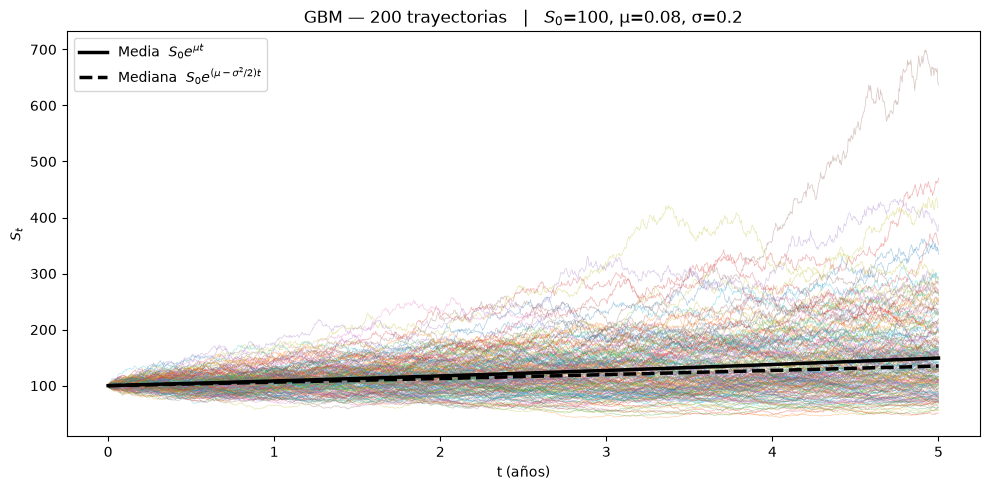

Fracción de trayectorias con S_T < E[S_T]:  0.595
Valor teórico Φ(σ√T/2):                     0.588


In [3]:
S0, MU, SIGMA = 100.0, 0.08, 0.20
T, N_PASOS    = 5.0, 5 * 252          # 5 años en pasos diarios
N_TRAY        = 200

tray  = simular_gbm(S0, MU, SIGMA, T, N_PASOS, N_TRAY, rng)
t_eje = np.linspace(0, T, N_PASOS + 1)

media_teo   = S0 * np.exp(MU * t_eje)
mediana_teo = S0 * np.exp((MU - 0.5 * SIGMA**2) * t_eje)

fig, ax = plt.subplots(figsize=(10, 5))
for i in range(N_TRAY):
    ax.plot(t_eje, tray[i], linewidth=0.5, alpha=0.35)
ax.plot(t_eje, media_teo,   'k-',  linewidth=2.5, label=r'Media  $S_0 e^{\mu t}$')
ax.plot(t_eje, mediana_teo, 'k--', linewidth=2.5, label=r'Mediana  $S_0 e^{(\mu - \sigma^2/2)t}$')
ax.set_xlabel('t (años)')
ax.set_ylabel('$S_t$')
ax.set_title(f'GBM — {N_TRAY} trayectorias   |   $S_0$={S0:.0f}, μ={MU}, σ={SIGMA}')
ax.legend()
plt.tight_layout()
plt.show()

frac_debajo = np.mean(tray[:, -1] < S0 * np.exp(MU * T))
print(f"Fracción de trayectorias con S_T < E[S_T]:  {frac_debajo:.3f}")
print(f"Valor teórico Φ(σ√T/2):                     {norm.cdf(SIGMA * np.sqrt(T) / 2):.3f}")

## 2.4 Validación: $S_T$ es lognormal

La fórmula del GBM dice que $\log S_T \sim \mathcal{N}\big(\log S_0 + (\mu - \sigma^2/2)T,\; \sigma^2 T\big)$; es decir, $S_T$ sigue una distribución **lognormal**. Validamos el simulador con dos comprobaciones:

1. El histograma de $S_T$ simulado contra la densidad lognormal teórica.
2. Los momentos Monte Carlo contra los teóricos:

$$
\mathbb{E}[S_T] = S_0\, e^{\mu T}, \qquad \operatorname{Var}(S_T) = S_0^2\, e^{2\mu T}\left(e^{\sigma^2 T} - 1\right)
$$

(La varianza sale de aplicar $\mathbb{E}[e^X] = e^{m + v/2}$ a $\mathbb{E}[S_T^2]$ — el mismo truco de la corrección de Jensen en 1.4.)


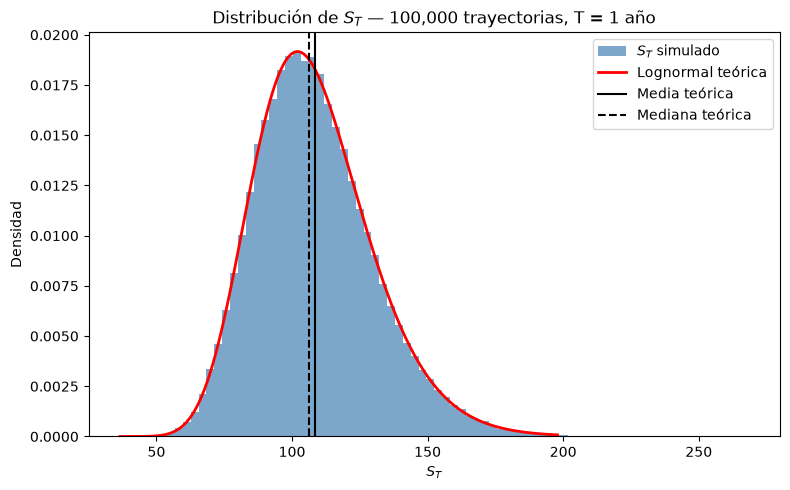

             Monte Carlo       Teórico
--------------------------------------
E[S_T]          108.3817      108.3287
DE(S_T)          21.9720       21.8842
Mediana         106.2741      106.1837


In [4]:
N_TRAY_VAL = 100_000
T_VAL      = 1.0

S_T = simular_gbm(S0, MU, SIGMA, T_VAL, 252, N_TRAY_VAL, rng)[:, -1]

# Lognormal en la convención de scipy:
#   s = desviación típica de log(S_T),  scale = exp(media de log(S_T))
dist_teo = lognorm(s=SIGMA * np.sqrt(T_VAL),
                   scale=S0 * np.exp((MU - 0.5 * SIGMA**2) * T_VAL))

x = np.linspace(S_T.min(), np.quantile(S_T, 0.999), 400)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(S_T, bins=80, density=True, color='steelblue', alpha=0.7, label='$S_T$ simulado')
ax.plot(x, dist_teo.pdf(x), 'r-', linewidth=2, label='Lognormal teórica')
ax.axvline(S0 * np.exp(MU * T_VAL), color='black', linestyle='-',  linewidth=1.5, label='Media teórica')
ax.axvline(dist_teo.median(),       color='black', linestyle='--', linewidth=1.5, label='Mediana teórica')
ax.set_xlabel('$S_T$')
ax.set_ylabel('Densidad')
ax.set_title(f'Distribución de $S_T$ — {N_TRAY_VAL:,} trayectorias, T = {T_VAL:.0f} año')
ax.legend()
plt.tight_layout()
plt.show()

de_teorica = np.sqrt(S0**2 * np.exp(2 * MU * T_VAL) * (np.exp(SIGMA**2 * T_VAL) - 1))
print(f"{'':10}  {'Monte Carlo':>12}  {'Teórico':>12}")
print("-" * 38)
print(f"{'E[S_T]':10}  {S_T.mean():>12.4f}  {S0 * np.exp(MU * T_VAL):>12.4f}")
print(f"{'DE(S_T)':10}  {S_T.std():>12.4f}  {de_teorica:>12.4f}")
print(f"{'Mediana':10}  {np.median(S_T):>12.4f}  {dist_teo.median():>12.4f}")

## 2.5 Midiendo el error de Euler–Maruyama

Para cuantificar el error de discretización usamos el **error fuerte**: la distancia media entre el valor final de Euler y el exacto, *construidos ambos con el mismo browniano*:

$$
e(\Delta t) = \mathbb{E}\big[\,\lvert S_T^{\text{Euler}} - S_T \rvert\,\big]
$$

La teoría (Kloeden & Platen) dice que Euler–Maruyama tiene **orden fuerte 1/2**: $e(\Delta t) = O(\Delta t^{1/2})$. Nótese que es peor que el orden 1 de Euler para EDOs deterministas — el ruido browniano degrada la convergencia.

El diseño del experimento sigue a Higham (*SIAM Review*, 2001): generamos los incrementos brownianos en la malla más fina y los **agregamos por bloques** para obtener *el mismo* browniano en mallas más gruesas. Así todas las discretizaciones comparten la misma fuente de aleatoriedad y la única diferencia entre ellas es $\Delta t$.


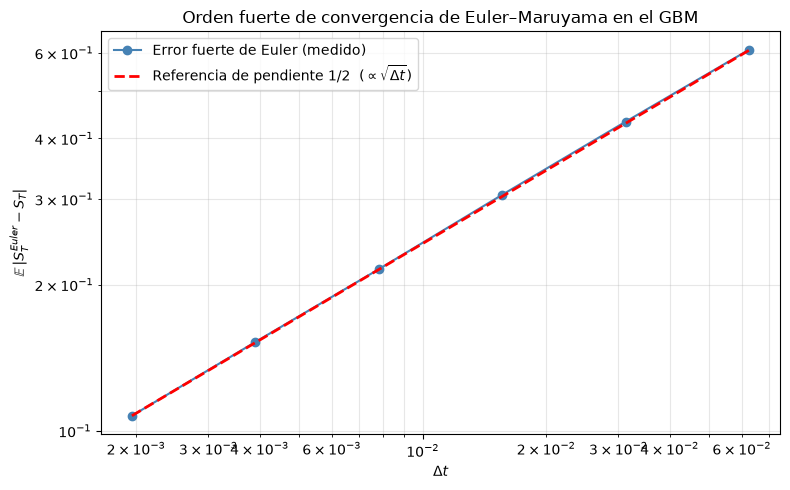

Pendiente ajustada en escala log-log: 0.501  (teórica: 0.5)


In [5]:
N_TRAY_ERR = 20_000
N_FINO     = 512                     # pasos de la malla más fina
T_ERR      = 1.0
dt_fino    = T_ERR / N_FINO

# Incrementos brownianos en la malla fina: ΔW ~ N(0, Δt)
dW = rng.normal(0, np.sqrt(dt_fino), size=(N_TRAY_ERR, N_FINO))

# Valor exacto de S_T con ese browniano: solo necesita W_T = suma de incrementos
W_T        = dW.sum(axis=1)
S_T_exacto = S0 * np.exp((MU - 0.5 * SIGMA**2) * T_ERR + SIGMA * W_T)

factores = [1, 2, 4, 8, 16, 32]      # factor de agrupado de la malla
dts, errores = [], []

for R in factores:
    n_pasos = N_FINO // R
    dt      = R * dt_fino
    # Sumar los incrementos finos en bloques de R → browniano en la malla gruesa
    dW_grueso = dW.reshape(N_TRAY_ERR, n_pasos, R).sum(axis=2)
    # Euler-Maruyama: S_{k+1} = S_k (1 + μΔt + σΔW_k) → producto de factores
    S_T_euler = S0 * np.prod(1 + MU * dt + SIGMA * dW_grueso, axis=1)
    dts.append(dt)
    errores.append(np.mean(np.abs(S_T_euler - S_T_exacto)))

dts, errores = np.array(dts), np.array(errores)

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(dts, errores, 'o-', color='steelblue', label='Error fuerte de Euler (medido)')
ax.loglog(dts, errores[0] * (dts / dts[0])**0.5, 'r--', linewidth=2,
          label=r'Referencia de pendiente 1/2  ($\propto \sqrt{\Delta t}$)')
ax.set_xlabel(r'$\Delta t$')
ax.set_ylabel(r'$\mathbb{E}\,|S_T^{Euler} - S_T|$')
ax.set_title('Orden fuerte de convergencia de Euler–Maruyama en el GBM')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

pendiente = np.polyfit(np.log(dts), np.log(errores), 1)[0]
print(f"Pendiente ajustada en escala log-log: {pendiente:.3f}  (teórica: 0.5)")

## 2.6 Recapitulación

Qué hemos establecido en esta sección:

1. La EDE del GBM, $dS_t = \mu S_t\, dt + \sigma S_t\, dW_t$, y su solución cerrada — verificada por Monte Carlo: media, mediana, desviación típica y distribución completa de $S_T$ coinciden con la teoría.
2. El **esquema exacto** de simulación, sin error de discretización, que será nuestro método por defecto siempre que trabajemos con GBM.
3. **Euler–Maruyama**, el esquema general para EDEs sin solución cerrada, y una medición empírica de su orden fuerte de convergencia $O(\sqrt{\Delta t})$.
4. Una lección conceptual importante: en un modelo lognormal, **la media no es la trayectoria típica** — la mayoría de las trayectorias quedan por debajo de $\mathbb{E}[S_t]$.

Hasta aquí, $\mu$ y $\sigma$ han sido números elegidos a mano. La pregunta natural de la **Sección 3** es: dados los precios históricos de un activo real, ¿cómo estimamos $\mu$ y $\sigma$? Ahí conectaremos el modelo con datos de mercado por primera vez.


---

# Sección 3 — Estimación de parámetros

Hasta ahora $\mu$ y $\sigma$ han sido números elegidos a mano. La pregunta de esta sección es la inversa: **dado el histórico de precios de un activo real, ¿qué valores de $\mu$ y $\sigma$ lo describen?** Este es el paso que conecta el modelo con el mercado — la *calibración*.

Usamos el ETF **SPY** (que replica el índice S&P 500) entre 2015 y 2023, descargado de Yahoo Finance. El precio se carga desde una copia cacheada en `data/` para que el notebook sea reproducible sin conexión; si el fichero no existe, se descarga y se guarda.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DIAS_ANIO = 252          # días de mercado por año → Δt = 1/252
TICKER    = "SPY"


def cargar_precios(ticker, inicio, fin):
    """Carga el cierre ajustado desde el CSV cacheado; si no está, lo descarga."""
    for carpeta in ("../data", "data"):        # el notebook vive en notebooks/
        cache = Path(carpeta) / f"{ticker.lower()}_prices.csv"
        if cache.exists():
            precios = pd.read_csv(cache, index_col="Date", parse_dates=True).iloc[:, 0]
            return precios.loc[inicio:fin]
    # Sin cache → descargar y guardar
    import yfinance as yf
    precios = yf.download(ticker, start=inicio, end=fin,
                          auto_adjust=True, progress=False)["Close"].squeeze()
    Path("../data").mkdir(exist_ok=True)
    precios.to_frame(ticker).to_csv("../data/" + f"{ticker.lower()}_prices.csv")
    return precios


precios = cargar_precios(TICKER, "2015-01-01", "2024-01-01")

# Rentabilidades logarítmicas diarias: r_t = log(S_t / S_{t-1})
log_ret = np.log(precios / precios.shift(1)).dropna()

print(f"{TICKER}: {len(precios)} precios de {precios.index[0].date()} a {precios.index[-1].date()}")
print(f"Rentabilidades logarítmicas diarias: {len(log_ret)}")

SPY: 2264 precios de 2015-01-02 a 2023-12-29
Rentabilidades logarítmicas diarias: 2263


## 3.1 Los datos: precio y rentabilidades logarítmicas

Antes de estimar nada, miramos los datos. El panel superior muestra el precio; el inferior, las rentabilidades logarítmicas diarias. Este segundo gráfico es el que de verdad importa, porque es el objeto que el GBM modela como ruido i.i.d. normal.

Fíjate ya en algo que anticipa la Sección 4: las oscilaciones **no** son homogéneas en el tiempo. Hay periodos tranquilos y estallidos de volatilidad muy marcados —el más visible, el desplome de marzo de 2020 (COVID)—. Esto se llama *agrupamiento de volatilidad* (volatility clustering), y es la primera grieta del supuesto i.i.d.: si las rentabilidades fueran verdaderamente independientes, no habría rachas.

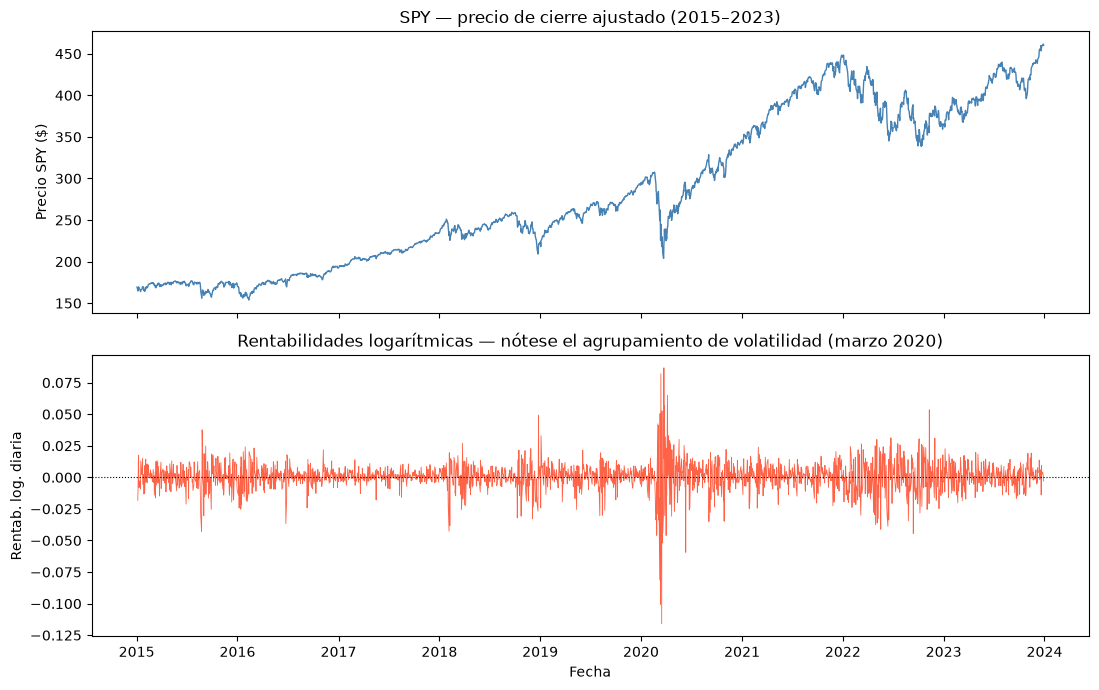

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

ax1.plot(precios.index, precios.values, color='steelblue', linewidth=1)
ax1.set_ylabel(f'Precio {TICKER} ($)')
ax1.set_title(f'{TICKER} — precio de cierre ajustado (2015–2023)')

ax2.plot(log_ret.index, log_ret.values, color='tomato', linewidth=0.6)
ax2.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax2.set_ylabel('Rentab. log. diaria')
ax2.set_xlabel('Fecha')
ax2.set_title('Rentabilidades logarítmicas — nótese el agrupamiento de volatilidad (marzo 2020)')

plt.tight_layout()
plt.show()

## 3.2 Estimadores de máxima verosimilitud

El modelo dice que las rentabilidades diarias son i.i.d. normales:

$$
r_t \sim \mathcal{N}(a, b^2), \qquad a = \left(\mu - \frac{\sigma^2}{2}\right)\Delta t, \qquad b^2 = \sigma^2 \Delta t
$$

con $\Delta t = 1/252$. Estimar $\mu$ y $\sigma$ se reduce entonces a estimar la media $a$ y la varianza $b^2$ de una normal a partir de una muestra i.i.d. Para eso usamos **máxima verosimilitud** (MLE).

La log-verosimilitud de $n$ observaciones es

$$
\ell(a, b^2) = -\frac{n}{2}\log(2\pi b^2) - \frac{1}{2b^2}\sum_{t=1}^{n}(r_t - a)^2
$$

Derivando e igualando a cero (las condiciones de primer orden) se obtienen los estimadores clásicos — la media y la varianza muestrales:

$$
\hat{a} = \frac{1}{n}\sum_{t=1}^{n} r_t, \qquad \hat{b}^2 = \frac{1}{n}\sum_{t=1}^{n}(r_t - \hat{a})^2
$$

(En la práctica usamos el divisor $n-1$ para $\hat b^2$ —el estimador insesgado—; con $n>2000$ la diferencia es irrelevante.) Deshaciendo el cambio de variable, **anualizamos**:

$$
\hat{\sigma} = \frac{\hat{b}}{\sqrt{\Delta t}} = \hat{b}\,\sqrt{252}, \qquad \hat{\mu} = \frac{\hat{a}}{\Delta t} + \frac{\hat{\sigma}^2}{2} = 252\,\hat{a} + \frac{\hat{\sigma}^2}{2}
$$

El término $+\hat\sigma^2/2$ es, de nuevo, la corrección de Jensen de la Sección 1.4: la media de las rentabilidades logarítmicas mide $\mu - \sigma^2/2$, así que hay que devolvérselo para recuperar $\mu$.

In [8]:
dt = 1 / DIAS_ANIO

a_hat = log_ret.mean()          # media muestral de las rentabilidades log diarias
b_hat = log_ret.std(ddof=1)     # desviación típica muestral (insesgada)

sigma_hat = b_hat / np.sqrt(dt)             # volatilidad anualizada
mu_hat    = a_hat / dt + 0.5 * sigma_hat**2  # drift anualizado (con corrección de Jensen)

print(f"Media diaria       â = {a_hat:.5f}")
print(f"DE diaria          b̂ = {b_hat:.5f}")
print("-" * 40)
print(f"Volatilidad   σ̂ = {sigma_hat:.4f}  ({sigma_hat*100:.2f}% anual)")
print(f"Drift         μ̂ = {mu_hat:.4f}  ({mu_hat*100:.2f}% anual)")

Media diaria       â = 0.00044
DE diaria          b̂ = 0.01144
----------------------------------------
Volatilidad   σ̂ = 0.1816  (18.16% anual)
Drift         μ̂ = 0.1279  (12.79% anual)


## 3.3 La volatilidad se estima bien; el drift, no

Tenemos dos números, $\hat\mu$ y $\hat\sigma$. Pero un número sin su barra de error no dice nada. Y aquí aparece el resultado más importante — y más contraintuitivo — de todo el módulo: **estos dos parámetros no se estiman con la misma calidad, ni de lejos.**

Los errores estándar de los estimadores son (resultado clásico para una muestra normal i.i.d.):

$$
\operatorname{SE}(\hat\sigma) \approx \frac{\sigma}{\sqrt{2n}}, \qquad \operatorname{SE}(\hat\mu) \approx \frac{\sigma}{\sqrt{T}}
$$

donde $n$ es el número de observaciones y $T = n\,\Delta t$ es el **horizonte temporal total en años**. La diferencia es estructural:

- $\operatorname{SE}(\hat\sigma)$ depende de $n$: más observaciones → mejor. Y $n$ se puede aumentar muestreando más a menudo (datos diarios en vez de mensuales).
- $\operatorname{SE}(\hat\mu)$ depende solo de $T$, el **calendario**: los $\Delta t$ se cancelan. Muestrear más a menudo **no ayuda en absoluto** a estimar el drift. Lo único que ayuda es observar más *años*, y los años pasan a un año por año.

Con $\sigma \approx 0.18$ y $T \approx 9$ años: $\operatorname{SE}(\hat\mu) \approx 0.18/3 = 0.06$. ¡Seis puntos porcentuales de error estándar sobre un drift que ronda el 10%! El intervalo de confianza del 95% para $\mu$ es de tipo $\hat\mu \pm 0.12$: ni siquiera podemos afirmar con seguridad que el drift sea positivo. Lo comprobamos con un experimento Monte Carlo: simulamos muchos historiales con $\mu$ y $\sigma$ **conocidos** y volvemos a estimarlos.

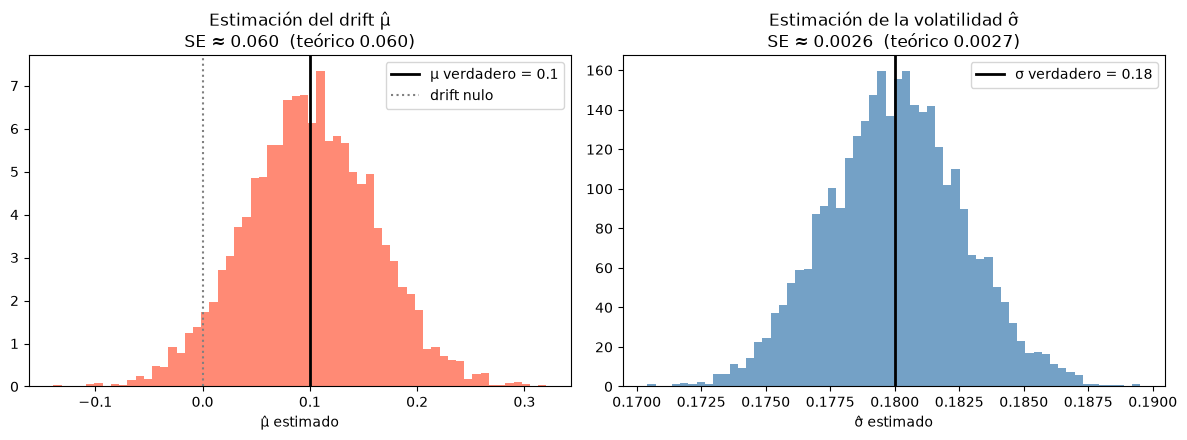

Fracción de historiales donde μ̂ sale NEGATIVO (siendo μ = 0.1 > 0): 4.8%


In [9]:
MU_VERDAD, SIGMA_VERDAD = 0.10, 0.18
T_OBS   = 9.0                       # años observados, como nuestros datos
N_PASOS = int(T_OBS * DIAS_ANIO)
N_REP   = 5_000                     # historiales independientes

# Cada fila es un historial de N_PASOS rentabilidades log diarias
r_sim     = rng.normal((MU_VERDAD - 0.5 * SIGMA_VERDAD**2) * dt,
                       SIGMA_VERDAD * np.sqrt(dt), size=(N_REP, N_PASOS))
sigma_est = r_sim.std(axis=1, ddof=1) / np.sqrt(dt)
mu_est    = r_sim.mean(axis=1) / dt + 0.5 * sigma_est**2

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.5))

axL.hist(mu_est, bins=60, color='tomato', alpha=0.75, density=True)
axL.axvline(MU_VERDAD, color='black', linewidth=2, label=f'μ verdadero = {MU_VERDAD}')
axL.axvline(0, color='gray', linestyle=':', linewidth=1.5, label='drift nulo')
axL.set_title(f'Estimación del drift μ̂\nSE ≈ {mu_est.std():.3f}  (teórico {SIGMA_VERDAD/np.sqrt(T_OBS):.3f})')
axL.set_xlabel('μ̂ estimado'); axL.legend()

axR.hist(sigma_est, bins=60, color='steelblue', alpha=0.75, density=True)
axR.axvline(SIGMA_VERDAD, color='black', linewidth=2, label=f'σ verdadero = {SIGMA_VERDAD}')
axR.set_title(f'Estimación de la volatilidad σ̂\nSE ≈ {sigma_est.std():.4f}  (teórico {SIGMA_VERDAD/np.sqrt(2*N_PASOS):.4f})')
axR.set_xlabel('σ̂ estimado'); axR.legend()

plt.tight_layout()
plt.show()

frac_neg = np.mean(mu_est < 0)
print(f"Fracción de historiales donde μ̂ sale NEGATIVO (siendo μ = {MU_VERDAD} > 0): {frac_neg:.1%}")

Los dos histogramas están a la misma escala mental pero cuentan historias opuestas: $\hat\sigma$ se concentra en un pisito estrecho alrededor del valor verdadero, mientras que $\hat\mu$ se desparrama tanto que una fracción nada despreciable de historiales — con drift verdadero **positivo** — produce una estimación **negativa**.

Para clavar la idea de que *la frecuencia de muestreo no ayuda al drift*, repetimos la estimación fijando $T = 9$ años pero cambiando cada cuánto observamos: anual, mensual, semanal, diario. El error del drift se queda clavado; el de la volatilidad se desploma.

In [10]:
frecuencias = {'Anual': 1, 'Mensual': 12, 'Semanal': 52, 'Diario': 252}

print(f"{'Frecuencia':<10} {'n obs':>7} {'SE(μ̂)':>10} {'SE(σ̂)':>10}")
print("-" * 40)
for nombre, freq in frecuencias.items():
    n_p   = int(T_OBS * freq)
    dt_f  = 1 / freq
    r_f   = rng.normal((MU_VERDAD - 0.5 * SIGMA_VERDAD**2) * dt_f,
                       SIGMA_VERDAD * np.sqrt(dt_f), size=(N_REP, n_p))
    s_est = r_f.std(axis=1, ddof=1) / np.sqrt(dt_f)
    m_est = r_f.mean(axis=1) / dt_f + 0.5 * s_est**2
    print(f"{nombre:<10} {n_p:>7} {m_est.std():>10.4f} {s_est.std():>10.4f}")

print("\nSE(μ̂) apenas se mueve al cambiar la frecuencia; SE(σ̂) cae con más observaciones.")

Frecuencia   n obs     SE(μ̂)     SE(σ̂)
----------------------------------------
Anual            9     0.0604     0.0447
Mensual        108     0.0603     0.0123
Semanal        468     0.0607     0.0059


Diario        2268     0.0601     0.0027

SE(μ̂) apenas se mueve al cambiar la frecuencia; SE(σ̂) cae con más observaciones.


**La consecuencia práctica es enorme y conviene interiorizarla ya:** en finanzas cuantitativas la volatilidad es un parámetro *estimable* y el drift esperado es, a efectos prácticos, *desconocido*. Por eso — como veremos en el Módulo 3 — la valoración de opciones no usa el drift real $\mu$ en absoluto: lo sustituye por la tasa libre de riesgo $r$ mediante la *valoración neutral al riesgo*, esquivando por completo el parámetro que no sabemos estimar. Lejos de ser un tecnicismo, es una respuesta directa a lo que acabamos de ver.

---

# Sección 4 — Validación

Tenemos un modelo calibrado. La pregunta final del módulo es: **¿de verdad se parece a la realidad?** La respondemos por dos vías: una visual (¿el precio real parece una trayectoria plausible del modelo?) y una estadística y crítica (¿se cumple el supuesto de normalidad?).

## 4.1 Trayectorias simuladas frente al precio real

Hacemos una validación *fuera de muestra*, que es la única honesta: calibramos $\mu$ y $\sigma$ con los datos **hasta el final de 2020** y, partiendo del último precio de ese periodo, simulamos hacia adelante los tres años siguientes (2021–2023). Sobre el abanico de trayectorias simuladas superponemos el precio **real** de ese periodo, que el modelo no ha visto.

Lo que buscamos no es que el modelo "acierte" el precio —es imposible, el futuro es aleatorio— sino que el precio real caiga **dentro** de la nube de escenarios plausibles: que sea un miembro creíble del conjunto que el GBM considera posible.

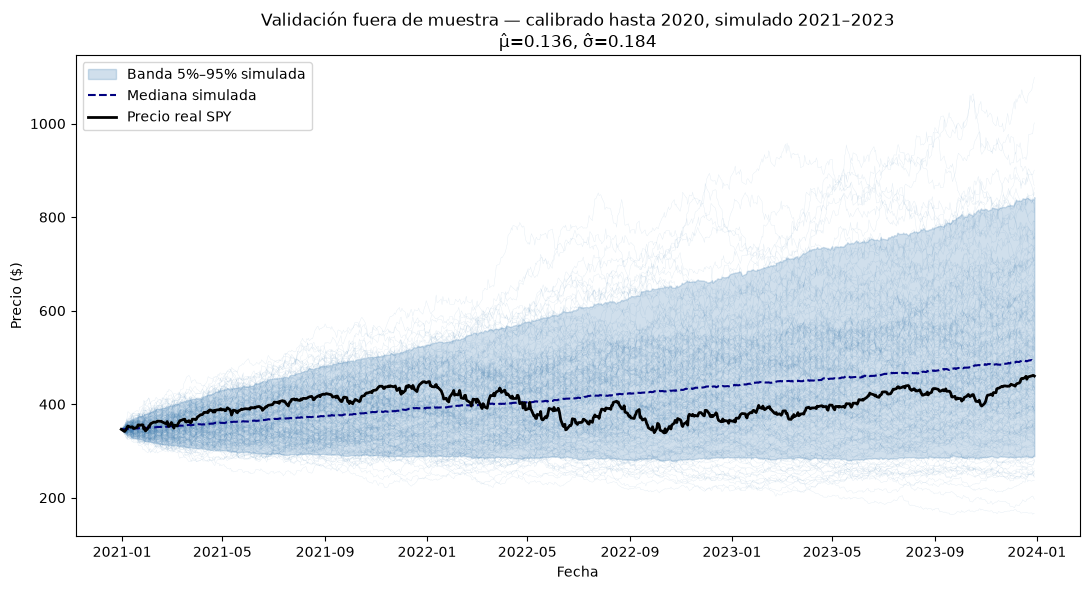

Precio real final: 460.25  →  percentil 42 de la distribución simulada


In [11]:
# Calibración solo con datos hasta 2020-12-31 (dentro de muestra)
r_train    = log_ret.loc[:'2020-12-31']
sigma_cal  = r_train.std(ddof=1) / np.sqrt(dt)
mu_cal     = r_train.mean() / dt + 0.5 * sigma_cal**2

# Periodo de prueba: desde el último precio de 2020 en adelante
precios_test = precios.loc['2020-12-31':]
fechas_test  = precios_test.index
S0_test      = precios_test.iloc[0]
n_pasos_test = len(fechas_test) - 1
T_test       = n_pasos_test / DIAS_ANIO

N_FAN = 2_000
tray_fan = simular_gbm(S0_test, mu_cal, sigma_cal, T_test, n_pasos_test, N_FAN, rng)

# Bandas de percentiles a lo largo del tiempo
p05, p50, p95 = np.percentile(tray_fan, [5, 50, 95], axis=0)

fig, ax = plt.subplots(figsize=(11, 6))
for i in range(200):                       # una muestra de trayectorias, de fondo
    ax.plot(fechas_test, tray_fan[i], color='steelblue', linewidth=0.3, alpha=0.15)
ax.fill_between(fechas_test, p05, p95, color='steelblue', alpha=0.25, label='Banda 5%–95% simulada')
ax.plot(fechas_test, p50, color='navy', linewidth=1.5, linestyle='--', label='Mediana simulada')
ax.plot(fechas_test, precios_test.values, color='black', linewidth=2, label=f'Precio real {TICKER}')
ax.set_xlabel('Fecha'); ax.set_ylabel('Precio ($)')
ax.set_title(f'Validación fuera de muestra — calibrado hasta 2020, simulado 2021–2023\nμ̂={mu_cal:.3f}, σ̂={sigma_cal:.3f}')
ax.legend()
plt.tight_layout()
plt.show()

# ¿En qué percentil de la distribución simulada cayó el precio final real?
S_final_real = precios_test.iloc[-1]
percentil = np.mean(tray_fan[:, -1] < S_final_real) * 100
print(f"Precio real final: {S_final_real:.2f}  →  percentil {percentil:.0f} de la distribución simulada")

## 4.2 ¿Se cumple la normalidad? Aquí es donde el modelo falla

La validación visual es favorable, pero es poco exigente. El supuesto duro del GBM es que las rentabilidades logarítmicas son **normales**. Lo ponemos a prueba con las herramientas estándar:

- **Q–Q plot:** cuantiles empíricos contra los de una normal. Si el supuesto se cumple, los puntos caen sobre la recta.
- **Asimetría (skewness)** y **curtosis en exceso (excess kurtosis):** para una normal ambas valen 0. En rentabilidades de renta variable se observa asimetría negativa (las caídas son más bruscas que las subidas) y curtosis positiva — **colas gruesas**: los eventos extremos son mucho más frecuentes de lo que predice la normal.
- **Test de Jarque–Bera:** contraste formal de normalidad basado en asimetría y curtosis. Un $p$-valor minúsculo rechaza la hipótesis de normalidad.

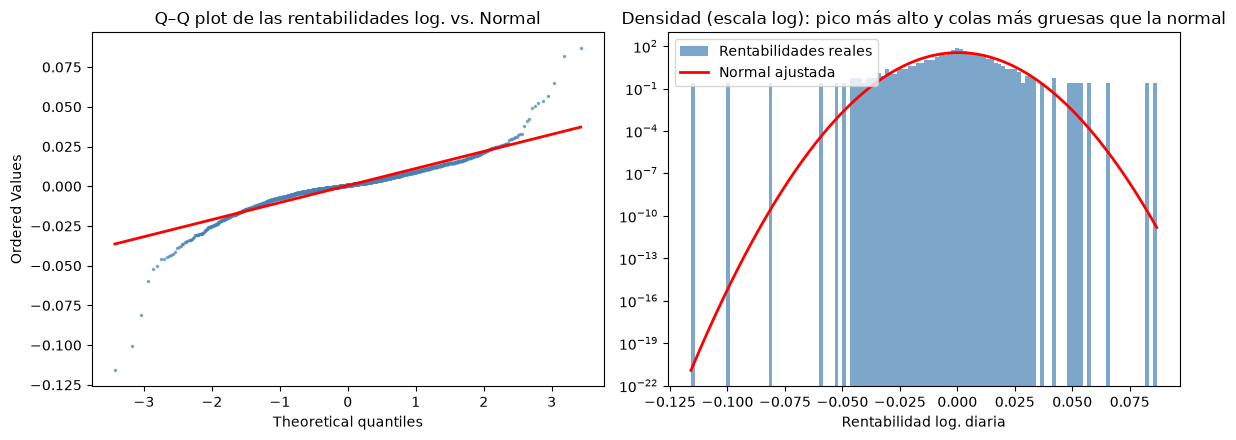

Asimetría (skewness):          -0.794   (normal: 0)
Curtosis en exceso:            13.478   (normal: 0)
Jarque–Bera: estadístico = 17,366,  p-valor = 0.00e+00

Peor día: -11.6%  =  10.2 desviaciones típicas
Prob. de un evento así bajo la normal: 1 cada 752,655,742,688,150,964,666,368 días de mercado


In [12]:
from scipy import stats

r = log_ret.values

fig, (axq, axh) = plt.subplots(1, 2, figsize=(12, 4.5))

# Q-Q plot contra la normal
stats.probplot(r, dist="norm", plot=axq)
axq.get_lines()[0].set(marker='.', markersize=3, color='steelblue', alpha=0.6)
axq.get_lines()[1].set(color='red', linewidth=2)
axq.set_title('Q–Q plot de las rentabilidades log. vs. Normal')

# Histograma vs normal ajustada
x = np.linspace(r.min(), r.max(), 400)
axh.hist(r, bins=120, density=True, color='steelblue', alpha=0.7, label='Rentabilidades reales')
axh.plot(x, stats.norm.pdf(x, r.mean(), r.std()), 'r-', linewidth=2, label='Normal ajustada')
axh.set_yscale('log')                      # escala log para ver las colas
axh.set_title('Densidad (escala log): pico más alto y colas más gruesas que la normal')
axh.set_xlabel('Rentabilidad log. diaria'); axh.legend()

plt.tight_layout()
plt.show()

asimetria = stats.skew(r)
curtosis  = stats.kurtosis(r)              # en exceso (Fisher): normal → 0
jb_stat, jb_p = stats.jarque_bera(r)

print(f"Asimetría (skewness):        {asimetria:>8.3f}   (normal: 0)")
print(f"Curtosis en exceso:          {curtosis:>8.3f}   (normal: 0)")
print(f"Jarque–Bera: estadístico = {jb_stat:,.0f},  p-valor = {jb_p:.2e}")
peor = log_ret.min()
print(f"\nPeor día: {peor*100:.1f}%  =  {abs(peor - r.mean())/r.std():.1f} desviaciones típicas")
print(f"Prob. de un evento así bajo la normal: 1 cada {1/stats.norm.sf(abs(peor-r.mean())/r.std()):,.0f} días de mercado")

## 4.3 Cierre del módulo

**Qué hemos construido.** Partiendo del movimiento browniano del Módulo 1, hemos derivado el GBM como el modelo natural para precios (Sección 1), lo hemos simulado y validado numéricamente con dos esquemas (Sección 2), lo hemos calibrado con datos reales de mercado (Sección 3) y lo hemos confrontado con la realidad (Sección 4).

**Qué funciona.** El GBM captura lo esencial: el crecimiento lognormal, un orden de magnitud correcto de la volatilidad, y genera un abanico de escenarios dentro del cual el precio real es un miembro plausible. Como modelo de referencia y como generador de escenarios, es sólido y es la base sobre la que se construye casi toda la teoría de valoración.

**Qué no funciona — el análisis honesto.** El supuesto de normalidad i.i.d. se rompe en dos frentes que los datos dejan clarísimos:

1. **Colas gruesas.** La curtosis en exceso es fuertemente positiva y Jarque–Bera rechaza la normalidad de forma aplastante. Los desplomes que el GBM considera casi imposibles (varias desviaciones típicas) ocurren en la práctica cada pocos años. Modelar esto exige saltos (modelos de difusión con saltos) o colas más pesadas.
2. **Agrupamiento de volatilidad.** La volatilidad no es constante: llega en rachas (marzo 2020). Las rentabilidades no son independientes en su magnitud. Capturarlo exige volatilidad estocástica (Heston) o modelos GARCH.
3. **El drift es, en la práctica, inestimable** (Sección 3.3) — la razón por la que la valoración neutral al riesgo lo evita.

**Puente al Módulo 3.** Con un modelo de precios en la mano y su principal limitación identificada, damos el salto a la primera aplicación financiera de verdad: **valorar una opción europea por Monte Carlo**. Simularemos el precio del subyacente bajo la medida neutral al riesgo (drift $= r$, no $\mu$ — justo lo que motivó la Sección 3.3), promediaremos el *payoff* descontado, y contrastaremos el resultado contra la fórmula cerrada de **Black–Scholes**. Ahí es donde Monte Carlo empieza a pagar de verdad.

## Referencias

- Higham, D. J. (2001). *An Algorithmic Introduction to Numerical Simulation of Stochastic Differential Equations*. SIAM Review, 43(3).
- Glasserman, P. (2003). *Monte Carlo Methods in Financial Engineering*, cap. 3.
- Hull, J. C. (2018). *Options, Futures and Other Derivatives*, cap. 15.
- Shreve, S. E. (2004). *Stochastic Calculus for Finance II*, cap. 4.